# Unsupervised Learning: Clustering Lab





In [1]:
!pip install yellowbrick
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd
from scipy.io import arff

## 1. Initial practice with the K-means and HAC algorithms

### 1.1 (10%) K-means
Run K-means on this [Abalone Dataset.](https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/abalone.arff)
The dataset was modified to be smaller. The last datapoint should be on line 359 or the point 0.585,0.46,0.185,0.922,0.3635,0.213,0.285,10. The remaining points are commented out. Treat the output class (last column) as an additional input feature. Create your K-Mmeans model with the paramaters K-means(n_clusters=3, init='random', n_init=1) 

Output the following:
- Class label for each point (labels_)
- The k=3 cluster centers (cluster_centers_)
- Number of iterations it took to converge (n_iter_)
- Total sum squared error of each point from its cluster center (inertia_)
- The total average silhouette score (see sklearn.metrics silhouette_score)

In [2]:
# Load data for lab
# Load abalone data
!curl -O https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/abalone.arff
# Load iris data
!curl -O https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/iris.arff

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  187k  100  187k    0     0   707k      0 --:--:-- --:--:-- --:--:--  708k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  7485  100  7485    0     0  38737      0 --:--:-- --:--:-- --:--:-- 38582


In [3]:
# K-means with Abalone

# Set up data and fit model
abalone, meta = arff.loadarff('abalone.arff')
abalone_df = pd.DataFrame(abalone)
k = 3
kmeans_model = KMeans(n_clusters=k, init='random', n_init=1) 
kmeans_model.fit(abalone_df)

print(f"Class labels: {kmeans_model.labels_}")
print(f"Cluster centers: {kmeans_model.cluster_centers_}")
print(f"Number of iterations to converge: {kmeans_model.n_iter_}")
print(f"SSE of points from cluster center: {kmeans_model.inertia_}")
print(f"Average silhouette score: {silhouette_score(abalone_df, kmeans_model.predict(abalone_df))}")

Class labels: [2 0 0 1 0 0 2 2 0 2 2 1 1 1 1 1 0 1 0 0 1 1 1 0 1 1 1 1 2 1 1 2 2 2 1 0 2
 0 1 0 0 2 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 1 1 1 0 1 0 2 1
 1 2 0 1 1 2 0 1 2 2 2 1 1 1 0 1 2 1 1 1 2 2 0 0 0 1 0 2 2 1 1 1 1 1 0 0 0
 0 0 0 1 1 1 1 0 0 0 0 2 0 0 0 0 0 2 2 2 0 0 0 0 0 0 0 0 0 1 1 2 1 1 1 1 0
 0 0 2 0 1 1 1 1 1 2 1 1 1 1 1 2 2 2 2 2 2 1 2 0 0 0 0 0 0 0 0 1 2 2 1 1 1
 1 1 1 1 0 1 1 2 0 1 1 1 2 2 1]
Cluster centers: [[ 0.40975309  0.31709877  0.10277778  0.39740741  0.16626543  0.09267284
   0.12505556  7.55555556]
 [ 0.55365385  0.43467949  0.15064103  0.89603846  0.35557051  0.19882051
   0.2839359  11.14102564]
 [ 0.61304878  0.48731707  0.16804878  1.2947439   0.49280488  0.26418293
   0.4462561  16.24390244]]
Number of iterations to converge: 3
SSE of points from cluster center: 507.80199513424765
Average silhouette score: 0.5009802235628156


#### Discussion
Discuss your results. Run it a few times. What happens? How did the cluster silhouette scores compare? <br>
Now play around with k. What happens to the clusters and silhouette scores?

**With each run of the code above, the initalization of the clusters are different, resulting in the points being assigned a different cluster label, even though the three different cluster centers remain relatively consistent.  Running the model a few times, it appears that it has an average convergence of about 5 iterations with an SSE of low 500s and average silhouette score with percentage around the low 50s.  The SSE and silhouette scores were fairly consistent throughout the runs.  With an increase of k, the SSE decreases quickly while the average silhouette score remains similar with only a slight average decrease in score.**

### 1.2 (10%) Hierarchical Agglomerative Clustering (HAC) 

Run HAC on the same [Abalone Dataset](https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/abalone.arff) using complete linkage and k=3.

Output the following:
- Class label for each point (labels_)
- The total average silhouette score

In [4]:
# HAC with Abalone
HAC_model = AgglomerativeClustering(n_clusters=3, linkage="complete")
HAC_model.fit(abalone_df)

print(f"Class labels: {HAC_model.labels_}")
print(f"Average silhouette score: {silhouette_score(abalone_df, HAC_model.fit_predict(abalone_df))}")

Class labels: [1 0 0 0 0 0 2 1 0 2 1 0 0 0 0 1 0 0 0 0 0 0 1 0 0 1 1 1 1 1 0 1 2 2 1 0 1
 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 1 0 2 1
 1 1 0 0 1 1 0 1 1 2 1 1 1 0 0 1 1 1 1 0 1 1 0 0 0 0 0 1 1 0 1 1 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 2 2 2 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0
 0 0 1 0 0 0 1 0 1 1 1 1 1 1 1 2 1 1 2 2 1 1 1 0 0 0 0 0 0 0 0 1 1 2 0 0 1
 1 1 0 1 0 1 1 1 0 0 1 0 1 1 0]
Average silhouette score: 0.5398112398376158


#### Discussion
How do the clusters compare to your results above? Explain the differences using what you know about HAC.

**With HAC, I get the same class labels for each run. This is due to its algorithm of iteratively combining close points and clusters, resulting in the same clusters for each run of the model.  We see that for the abalone data, HAC performs similarly to KMeans, with maybe a slight improvement in average silhouette score.**

## 2. K-means Clustering with the [Iris Dataset](https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/iris.arff)
Use the Iris data set for 2.1 and 2.2.  Don't include the output label as one of the input features.

### 2.1 (20%) K-means Initial Centroids Experiments
K-means results differ based on the initial centroids used.
- Run K-means 5 times with *k*=4, each time with different initial random centroids (init="random) and with n_init=1.  Give inertia and silhouette scores for each run and discuss any variations in the results.
- SKlearn has a parameter that does this automatically (n_init).  n_init = z runs K-means z times, each with different random centroids and returns the clustering with the best SSE (intertia) of the z runs. Try it out and discuss how it does and how it compares with your 5 runs above.
- Sklearn also has a parameter (init:'K-means++') which runs a simpler fast version of K-means first on the data to come up with good initial centroids, and then runs regular K-means with this centroids.  Try it out (with n_init = 1) and discuss.

In [5]:
# K-means initial centroid experiments

# Set up data
iris, meta = arff.loadarff('iris.arff')
iris_df = pd.DataFrame(iris).drop(columns=["class"])

# Run K-means 5 times with k = 4
results1 = []
for i in range(5):
    k = 4
    kmeans_model1 = KMeans(n_clusters=k, init='random', n_init=1, random_state=i+1) 
    kmeans_model1.fit(iris_df)
    run_stats = {"inertia": kmeans_model1.inertia_, "silhouette_score": silhouette_score(iris_df, kmeans_model1.predict(iris_df))}
    results1.append(run_stats)

print(f"Results with K-means with init='random' and n_init=1")
display(pd.DataFrame(results1))

# Run SKlearn with n_init=5
results2 = []
for i in range(5):
    kmeans_model2 = KMeans(n_clusters=k, n_init=5, random_state=i) 
    kmeans_model2.fit(iris_df)
    run_stats = {"inertia": kmeans_model2.inertia_, "silhouette_score": silhouette_score(iris_df, kmeans_model2.predict(iris_df))}
    results2.append(run_stats)

print(f"Results with K-means with n_init=5")
display(pd.DataFrame(results2))

# Run SKlearn init:'K-means++'
results3 = []
for i in range(5):
    kmeans_model3 = KMeans(n_clusters=k, init='k-means++', n_init=1, random_state=i) 
    kmeans_model3.fit(iris_df)
    run_stats = {"inertia": kmeans_model3.inertia_, "silhouette_score": silhouette_score(iris_df, kmeans_model3.predict(iris_df))}
    results3.append(run_stats)

print(f"Results with K-means with init='K-means++' and n_init=1")
display(pd.DataFrame(results3))

Results with K-means with init='random' and n_init=1


,inertia,silhouette_score
0,71.340447,0.417105
1,57.345409,0.497228
2,57.345409,0.497228
3,57.473273,0.495120
4,71.657090,0.413818


Results with K-means with n_init=5


,inertia,silhouette_score
0,57.317873,0.497826
1,57.345409,0.497228
2,57.317873,0.497826
3,57.317873,0.497826
4,57.345409,0.497228


Results with K-means with init='K-means++' and n_init=1


,inertia,silhouette_score
0,57.317873,0.497826
1,57.473273,0.495120
2,57.317873,0.497826
3,57.317873,0.497826
4,71.340447,0.417105


#### Discussion
Discuss your results. How does n_init work and compare with your first results without using n_init. <br>
How does K-means++ work? Compare it to your previous runs.

**For my initial 5 runs of K-means, I tend to get two different outcomes, one with inertia 71 and silhouette_score 0.417 and the other with inertia 57 and silhouette_score 0.49.  When I use n_init=5 to find the best model over 5 runs, I get the lower inertia of 57 nearly every time versus the first results when I only got it a bit over half of the time. Using K-means++ to get a better initialization of the centroids, the model achieves an inertia of 57 more frequently but not as consistently as using n_init.**

### 2.2 (20%) Silhouette Graphs
In this part you will show silhouette graphs for different *k* values.  Install the [Yellowbrick visualization package](https://www.scikit-yb.org/en/latest/quickstart.html) and import the [Silhouette Visualizer](https://www.scikit-yb.org/en/latest/api/cluster/silhouette.html).  This library includes lots of visualization packages which you might find useful. (Note: The YellowBrick silhouette visualizer does not currently support HAC).
- Show Silhouette graphs for clusterings with *k* = 2-6. Print the SSE (inertia) and total silhouette score for each.
- Learn with the default n_init = 10 to help insure a decent clustering.
- Using the silhouette graphs, choose which *k* you think is best and discuss why. Think about and discuss more than just the total silhouette score.

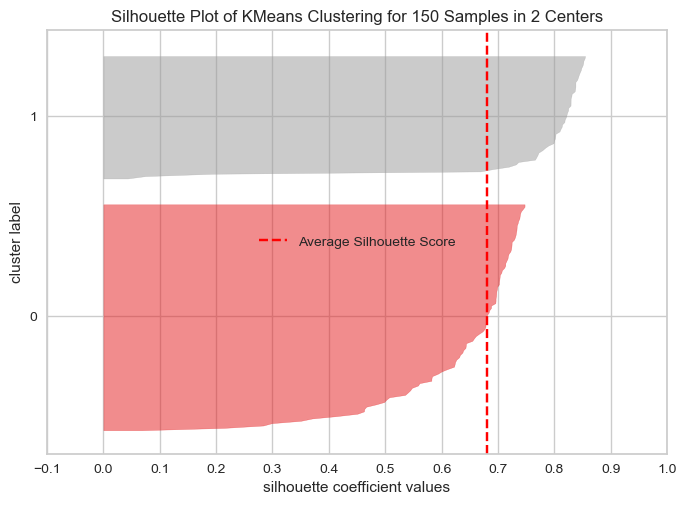

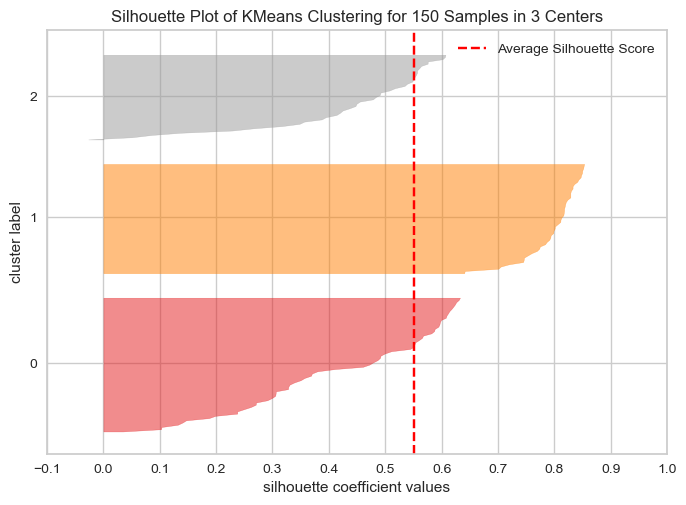

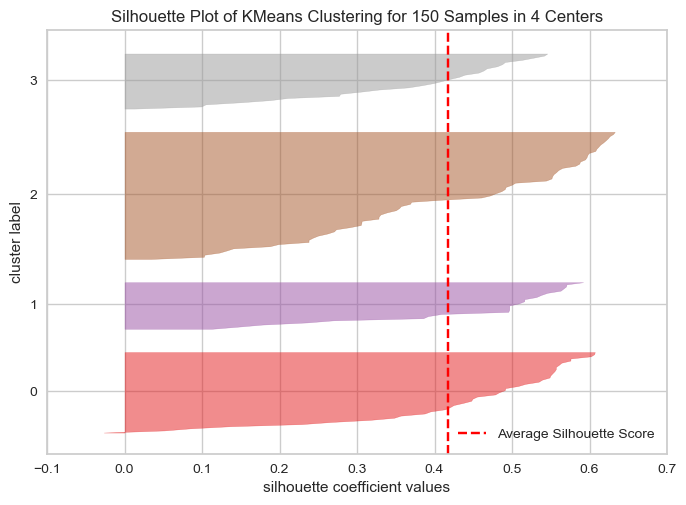

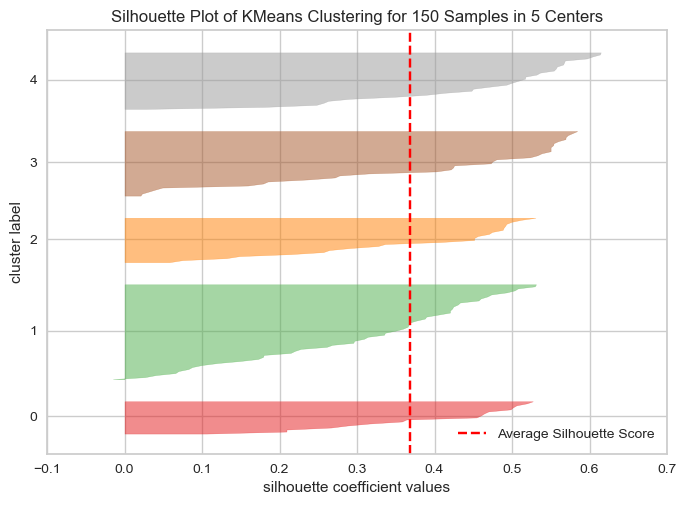

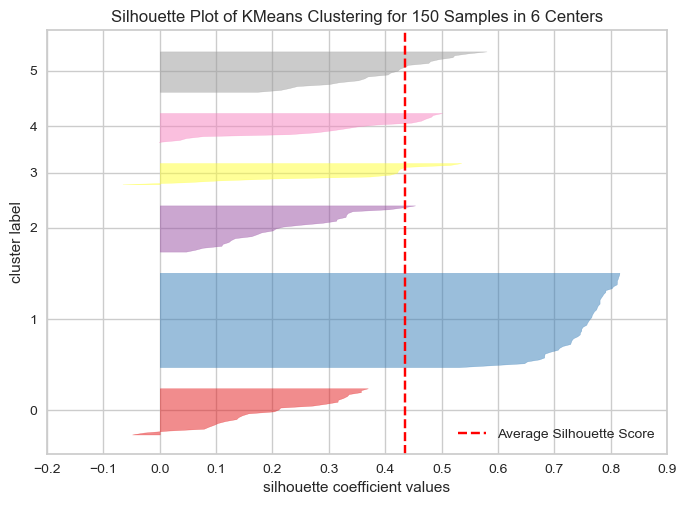

Results with K-means with k = 2-6


,k,inertia,silhouette_score
0,2,152.368706,0.680814
1,3,78.945066,0.550964
2,4,71.340447,0.417105
3,5,50.187724,0.368969
4,6,43.103680,0.435990


In [6]:
# Iris Clustering with K-means and silhouette graphs
from yellowbrick.cluster import SilhouetteVisualizer

# Set up data
iris, meta = arff.loadarff('iris.arff')
iris_df = pd.DataFrame(iris).drop(columns=["class"])

results = []
for k in range(2, 7):
    kmeans_model = SilhouetteVisualizer(KMeans(n_clusters=k, random_state=k), )
    kmeans_model.fit(iris_df)
    run_stats = {"k": k, "inertia": kmeans_model.inertia_, "silhouette_score": silhouette_score(iris_df, kmeans_model.predict(iris_df))}
    results.append(run_stats)
    kmeans_model.show()

print(f"Results with K-means with k = 2-6")
display(pd.DataFrame(results))

#### Discussion
Discuss your results and justify which clustering is best based on the silhouette graphs

**From the table of run statistics, we see that as the k increases, the inertia and silhouette_score tend to decrease, making it difficult to determine which model is best.  If we choose the best clustering based purely off of the silhouette graphs, it would be the model with k=2 as it achieves the highest silhouette_score.  Taking into account the large drop in inertia from k=2 to k=3 despite the drop in silhouette_score, it could be argued that k=3 is actually the best clustering.**

## 3 (20%) Iris Clustering with HAC

- Use the same dataset as above and learn with HAC clustering
- Create one table with silhouette scores for k=2-6 for each of the linkage options single, average, complete, and ward

In [7]:
#HAC with Iris
# Set up data
iris, meta = arff.loadarff('iris.arff')
iris_df = pd.DataFrame(iris).drop(columns=["class"])

results = []
for linkage_method in ['single', 'average', 'complete', 'ward']:
    for k in range(2, 7):
        HAC_model = AgglomerativeClustering(n_clusters=k, linkage=linkage_method)
        HAC_model.fit(iris_df)
        run_stats = {"k": k, "linkage": linkage_method, "silhouette_score": silhouette_score(iris_df, HAC_model.fit_predict(iris_df))}
        results.append(run_stats)
        kmeans_model.show()

print("Results with HAC for different linkage methods for k = 2-6")
display(pd.DataFrame(results))

Results with HAC for different linkage methods for k = 2-6


,k,linkage,silhouette_score
0,2,single,0.686393
1,3,single,0.511839
2,4,single,0.281778
3,5,single,0.283484
4,6,single,0.221114
5,2,average,0.686393
6,3,average,0.553934
7,4,average,0.471665
8,5,average,0.430342
9,6,average,0.340659


#### Discussion
Discuss your results and compare with your k-means results. <br>
Discuss your table that contains the silhouette scores for k=2,3,4,5,6 and for each of the different linkage options. <br>
Discuss how the linkage options affect your scores.

**The results shown in the table are very similar to the k-means results with most linkage methods achieving a silhouette_score of 0.68 for k=2 and decreasing as k increases.  A few of the linkage methods get a higher silhouette_score than k-means for higher values of k.  As for results between the methods, it appears that k=2 and k=3 perform the best and ward linkage performs the best overall between the linkage methods, achieving the highest or near highest silhouette_score for each value of k.  The difference in linkage method does not appear to make huge differences in the results, but there are some definite differences with some linkage methods performing much worse at high values of k than others.**

## 4 (20%) Run both algorithms on a real world data
- Choose any real world data set which you have not used previously
- Use parameters of your choosing
- Try each algorithm a few times with different parameters and output one typical example of labels and silhouette scores for each algorithm
- Show the silhouette graph for at least one reasonable *k* value for K-means

In [8]:
#!/bin/bash
# !curl -L -o ~/Downloads/mushroom-classification.zip\
#   https://www.kaggle.com/api/v1/datasets/download/uciml/mushroom-classification

Example labels for kmeans_model: [1 1 1 ... 1 0 1]


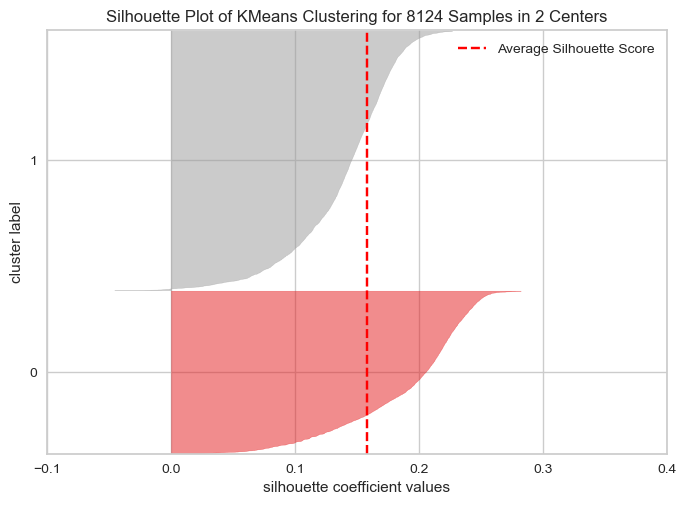

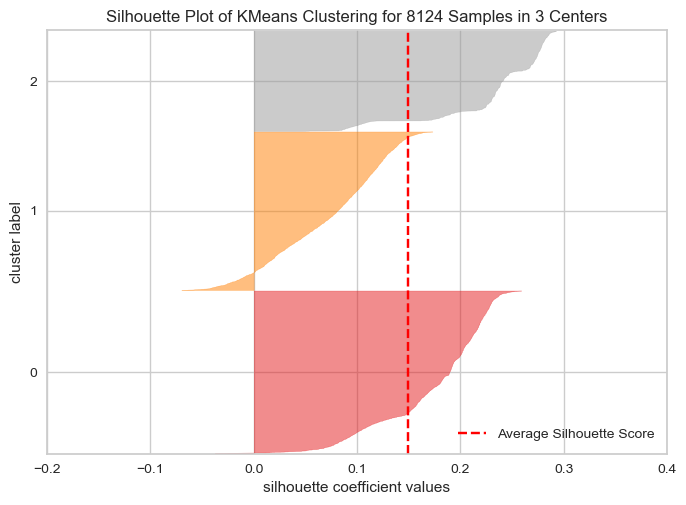

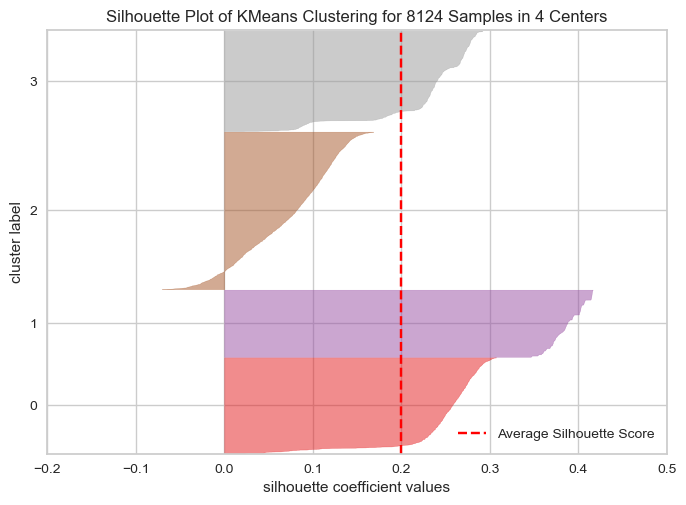

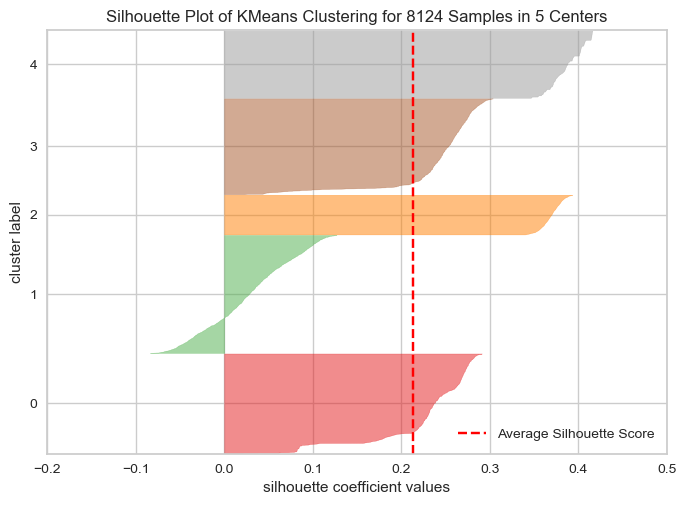

Results with K-means for k = 2-6


,k,inertia,silhouette_score
0,2,62275.143278,0.158390
1,3,56878.680688,0.148960
2,4,48844.251011,0.199085
3,5,45604.771679,0.213034


Example labels for HAC_model: [0 0 0 ... 0 0 0]
Results with HAC for different linkage methods for k = 2 and k = 3


,k,linkage,silhouette_score
0,2,single,0.153297
1,3,single,0.149256
2,2,average,0.146760
3,3,average,0.170873
4,2,complete,0.110110
5,3,complete,0.119383
6,2,ward,0.155665
7,3,ward,0.183506


In [28]:
# Run both algoriths on a data set of your choice
mushrooms_df = pd.read_csv("/Users/prestonhancock/Desktop/cs270/Clustering_Lab/mushrooms.csv")
mushrooms_df = mushrooms_df.drop(columns=["class"])
# mushrooms_df = mushrooms_df.drop(columns=["stalk-shape","stalk-root","stalk-surface-above-ring","stalk-surface-below-ring","stalk-color-above-ring","stalk-color-below-ring","veil-type","veil-color","ring-number","ring-type","spore-print-color","population","habitat"])
mushrooms_df = pd.get_dummies(mushrooms_df, drop_first=True)

# Try K-means
results = []
for k in range(2, 6):
    kmeans_model = SilhouetteVisualizer(KMeans(n_clusters=k, init='random', n_init=1, random_state=k))
    kmeans_model.fit(mushrooms_df)
    if k == 2:
        print(f"Example labels for kmeans_model: {kmeans_model.labels_}")
    run_stats = {"k": k, "inertia": kmeans_model.inertia_, "silhouette_score": silhouette_score(mushrooms_df, kmeans_model.predict(mushrooms_df))}
    results.append(run_stats)
    kmeans_model.show()

print(f"Results with K-means for k = 2-6")
display(pd.DataFrame(results))

# Try HAC
results = []
for linkage_method in ['single', 'average', 'complete', 'ward']:
    for k in range(2, 4):
        HAC_model = AgglomerativeClustering(n_clusters=k, linkage=linkage_method)
        HAC_model.fit(mushrooms_df)
        if k == 2 and linkage_method == 'single':
            print(f"Example labels for HAC_model: {HAC_model.labels_}")
        run_stats = {"k": k, "linkage": linkage_method, "silhouette_score": silhouette_score(mushrooms_df, HAC_model.fit_predict(mushrooms_df))}
        results.append(run_stats)

print("Results with HAC for different linkage methods for k = 2 and k = 3")
display(pd.DataFrame(results))


#### Discussion 
Discuss your results and compare the algorithms you used. Which worked best? How do you know? Base your discussion on what you know about the algorithms and the hyperparameters and scoring methods. Why would you choose either algorithm?

**I chose to use a dataset about mushrooms and determining whether they were edible or poisonous.  Using the k-means model, varying the value of k did not change the silhouette score much, and from the graphs, I can see that k=2 is likely the best as it does not have any points with negative silhouette scores and both groups have similar numbers of instances.  The HAC model performs similarly for the difference linkage methods, other than "complete" not performing very well. Since I can't see the silhouette graphs for the HAC model it is hard to say which would be ideal, but since it was seen in kmeans that k=2 was best, I would assume the k=2 would be best for the HAC models as well, thus making the HAC model with ward linkage the best since it has the highest silhouette score of the different methods. Since the dataset in use is fairly complex, it is difficult to know for sure whether the KMeans or HAC model performs the best overall.  If I wanted to get consistent results, I would choose the HAC model, but if I wanted more variability and possible a better final result, I would choose to use KMeans.**

## 5. Extra Credit for Coding Your Own Clustering Algorithms
### 5.1 (Optional 10% extra credit) Code up the K-means clustering algorithm 
Below is a scaffold you could use if you want. As above, you only need to support numeric inputs, but think about how you would support nominal inputs and unknown values. Requirements for this task:
- Your model should support the methods shown in the example scaffold below.
- Ability to choose *k* and specify the *k* initial centroids.
- Run and show the cluster label for each point with both the Iris data set and the data set of your choice above.

### 5.2 (Optional 10% extra credit) Code up the HAC clustering algorithm 

- Your model should support the methods shown in the example scaffold below.
- HAC should support both single link and complete link options.
- HAC automatically generates all clusterings from *n* to 2.  You just need to output results for the curent chosen *k*.
- Run and show the cluster label for each point with both the Iris data set and the data set of your choice above.

#### Discussion
Discussion and comparision of each model implemented

** Your discussion goes here **

In [10]:
from sklearn.base import BaseEstimator, ClassifierMixin, ClusterMixin

class KMEANSClustering(BaseEstimator,ClusterMixin):

    def __init__(self,k=3,debug=False): ## add parameters here
        """
        Args:
            k = how many final clusters to have
            debug = if debug is true use the first k instances as the initial centroids otherwise choose random points as the initial centroids.
        """
        self.k = k
        self.debug = debug

    def fit(self, X, y=None):
        """ Fit the data; In this lab this will make the K clusters :D
        Args:
            X (array-like): A 2D numpy array with the training data
            y (array-like): An optional argument. Clustering is usually unsupervised so you don't need labels
        Returns:
            self: this allows this to be chained, e.g. model.fit(X,y).predict(X_test)
        """
        return self
    
    def print_labels(self): # Print the cluster label for each data point
        pass

In [11]:
class HACClustering(BaseEstimator,ClusterMixin):

    def __init__(self,k=3,link_type='single'): ## add parameters here
        """
        Args:
            k = how many final clusters to have
            link_type = single or complete. when combining two clusters use complete link or single link
        """
        self.link_type = link_type
        self.k = k
        
    def fit(self, X, y=None):
        """ Fit the data; In this lab this will make the K clusters :D
        Args:
            X (array-like): A 2D numpy array with the training data
            y (array-like): An optional argument. Clustering is usually unsupervised so you don't need labels
        Returns:
            self: this allows this to be chained, e.g. model.fit(X,y).predict(X_test)
        """
        return self
    
    def print_labels(self): # Print the cluster label for each data point
        pass